In [15]:
'''
Names: Prashant Ram
Course: CSC 177
Assignment: 1 - Data Preprocessing
Professor: Chidella
Details: This project deals with preprocessing data from a .csv file to ready it for
        data mining.
'''

import pandas
import matplotlib.pyplot as matPlot
import seaborn

In [17]:
'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe
    data = pandas.read_csv('lung_disease_data.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Age', 'Gender', 'Smoking Status', 'Lung Capacity', 'Disease Type',
       'Treatment Type', 'Hospital Visits', 'Recovered'],
      dtype='object')
We have 5200 rows
We have 8 columns

     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
1  34.0  Female            Yes            NaN   Bronchitis        Surgery   
2  80.0    Male            Yes           1.95         COPD            NaN   
3  40.0  Female            Yes            NaN   Bronchitis     Medication   
4  43.0    Male            Yes           4.60         COPD        Surgery   

   Hospital Visits Recovered  
0             14.0       Yes  
1              7.0        No  
2              4.0       Yes  
3              1.0        No  
4              NaN       Yes  


In [19]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

Age: 300
Gender: 300
Smoking Status: 300
Lung Capacity: 300
Disease Type: 300
Treatment Type: 300
Hospital Visits: 300
Recovered: 300

These columns had missing data: ['Age', 'Gender', 'Smoking Status', 'Lung Capacity', 'Disease Type', 'Treatment Type', 'Hospital Visits', 'Recovered']


In [7]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 5200 [original] rows and 8 columns

Original Data:     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
1  34.0  Female            Yes            NaN   Bronchitis        Surgery   
2  80.0    Male            Yes           1.95         COPD            NaN   
3  40.0  Female            Yes            NaN   Bronchitis     Medication   
4  43.0    Male            Yes           4.60         COPD        Surgery   

   Hospital Visits Recovered  
0             14.0       Yes  
1              7.0        No  
2              4.0       Yes  
3              1.0        No  
4              NaN       Yes  

We have 3236 [Clean] rows and 8 columns

Cleaned data Data:     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
5  22.0  Female             No           3.65   Bronchitis     Medication   


In [9]:
'''
This block converts the categorical columns to numeric types so they can be compared
'''
#Convert gender column to numeric
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
print('Gender Column.................DONE')

#Convert Smoking Status Column to Numeric
data['Smoking Status'] = data['Smoking Status'].map({'Yes': 1, 'No': 0})
print('Smoking Status Column.........DONE')

#Convert Recovered Column to Numeric
data['Recovered'] = data['Recovered'].map({'Yes': 1, 'No': 0})
print('Recovered Column..............DONE')

#Convert Disease and Treatment Type Column to Numeric
data = pandas.get_dummies(data, columns=['Disease Type', 'Treatment Type'], drop_first=True)
print('Disease Column................DONE')
print('Treatment Column..............DONE')


Gender Column.................DONE
Smoking Status Column.........DONE
Recovered Column..............DONE
Disease Column................DONE
Treatment Column..............DONE


In [11]:
# Convert boolean columns to integers 1 for True and 0 for False
data = data.astype(int)

#save the dataset using the new split data columns for Disease Type and Treatment Type
try:
    data.to_csv('lung_disease_cleaned.csv', index=False)
    print('Data saved to <<<lung_disease_cleaned.csv>>> with new columns WITHOUT converting TRUE/FALSE values to binary!')
    print('\n', data.head())
except Exception as e:
    print("Couln't save the cleaned data file!")

Data saved to <<<lung_disease_cleaned.csv>>> with new columns WITHOUT converting TRUE/FALSE values to binary!

    Age  Gender  Smoking Status  Lung Capacity  Hospital Visits  Recovered  \
0   71       1               0              4               14          1   
5   22       1               0              3               11          1   
6   41       0               1              2               12          1   
8   21       1               0              4               12          0   
9   49       0               1              5               11          1   

   Disease Type_Bronchitis  Disease Type_COPD  Disease Type_Lung Cancer  \
0                        0                  1                         0   
5                        1                  0                         0   
6                        0                  0                         0   
8                        0                  0                         1   
9                        0                  0     

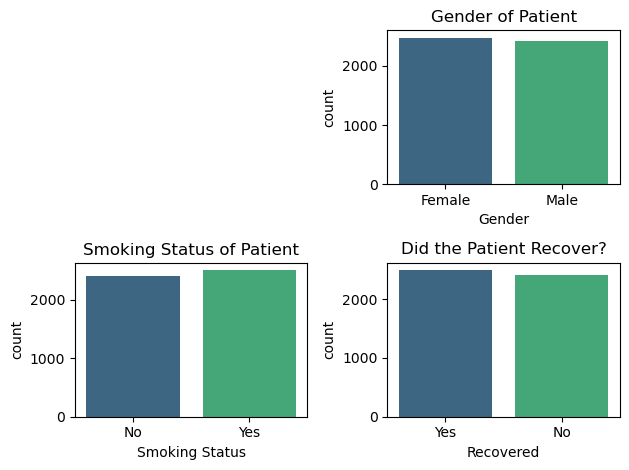

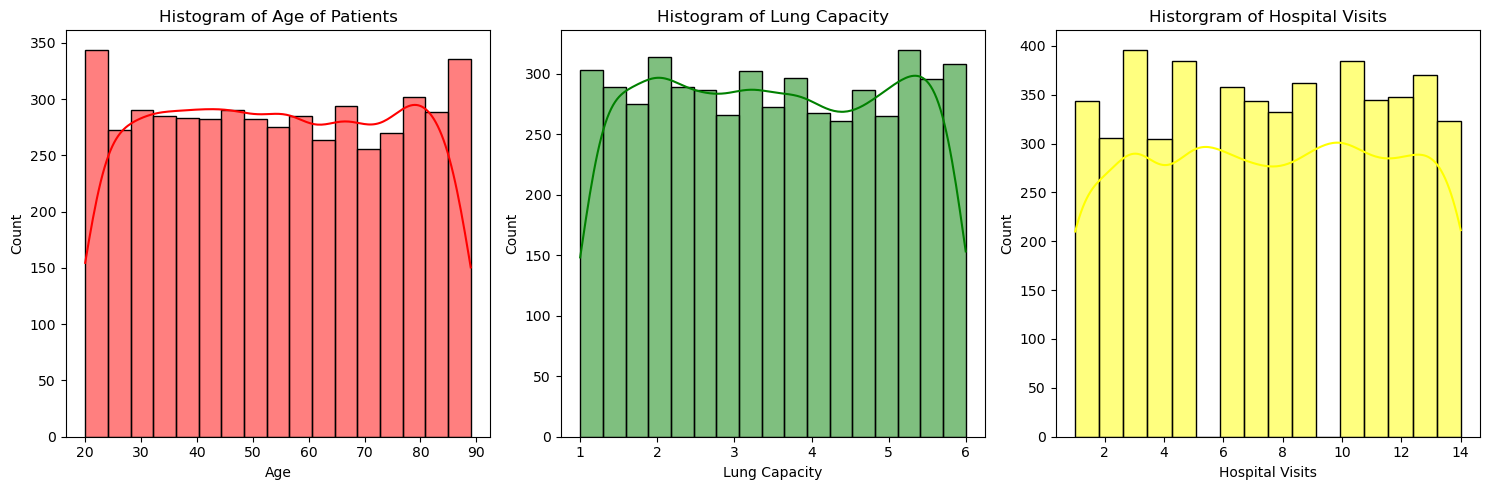

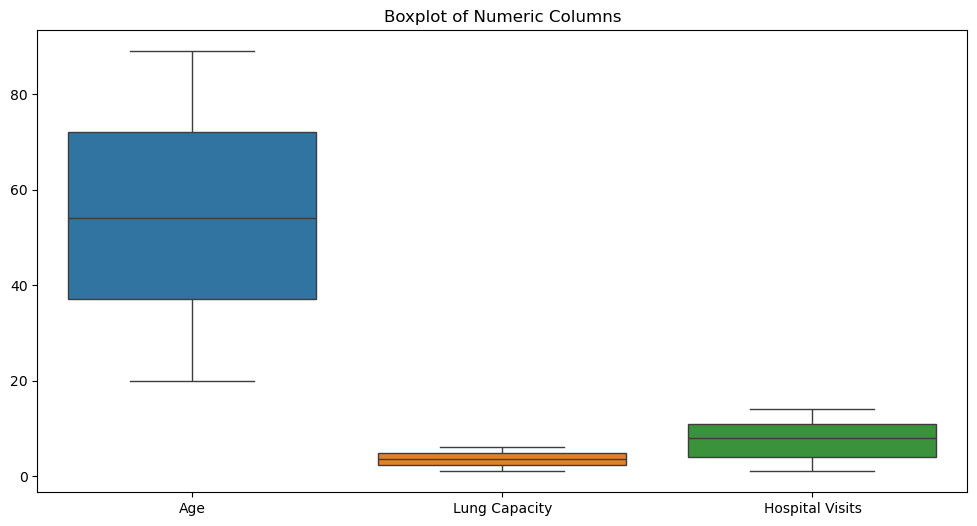

In [21]:
'''
Plots the data from the current dataframe for the individual columns
'''
#plot the Gender column
matPlot.subplot(2,2,2)
seaborn.countplot(x='Gender', data=data, hue='Gender', palette='viridis', legend=False)
matPlot.title('Gender of Patient')

#plot the Smoking Status column
matPlot.subplot(2,2,3)
seaborn.countplot(x='Smoking Status', data=data, hue='Smoking Status', palette='viridis', legend=False)
matPlot.title('Smoking Status of Patient')

#plot the Recovered column
matPlot.subplot(2,2,4)
seaborn.countplot(x='Recovered', data=data, hue='Recovered', palette='viridis', legend=False)
matPlot.title('Did the Patient Recover?')

#make the charts fit nicely together in one window
matPlot.tight_layout()

'''
Histogram plot of numerical columns
'''
# Plot histograms for numerical columns
matPlot.figure(figsize=(15, 5))

# Age
matPlot.subplot(1, 3, 1)
seaborn.histplot(data['Age'], kde=True, color='red')
matPlot.title('Histogram of Age of Patients')

# Lung Capacity
matPlot.subplot(1, 3, 2)
seaborn.histplot(data['Lung Capacity'], kde=True, color='green')
matPlot.title('Histogram of Lung Capacity')

# Hospital Visits
matPlot.subplot(1, 3, 3)
seaborn.histplot(data['Hospital Visits'], kde=True, color='yellow')
matPlot.title('Historgram of Hospital Visits')

matPlot.tight_layout()
matPlot.show()

'''
Boxplot of numerical columns
'''
#choose figure size for the plot area
matPlot.figure(figsize=(12, 6))
seaborn.boxplot(data=data[['Age', 'Lung Capacity', 'Hospital Visits']])
matPlot.title("Boxplot of Numeric Columns")
#display the data
matPlot.show()
